<a href="https://colab.research.google.com/github/Zetastico/Inteligencia-Artificial-I/blob/main/Laboratorio_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 02

### Usamos estas librerias para poder leer el dataset, graficar el costo y hacer los cálculos matemáticos necesarios.

In [49]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

### Le damos acceso a colab a nuestro drive para que pueda encontrar el archivo

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Aquí recogemos las filas y columnas que vamos a usar para entrenar a nuestros modelos y los guardamos en sus respectivas variables.

In [51]:
# Direccion del dataset
path = '/content/drive/MyDrive/IA Dataset/Dataset_Regresion_Lineal_Simple.csv'
df = pd.read_csv(path)
# Definimos las 20 variables
columnas_20 = [
    'experience_years',
    'bonus_usd',
    'interview_rounds',
    'weekly_hours',
    'company_rating',
    'job_openings',
    'hiring_difficulty_score',
    'layoff_risk',
    'ai_adoption_score',
    'company_funding_billion',
    'economic_index',
    'ai_maturity_years',
    'offer_acceptance_rate',
    'tax_rate_percent',
    'vacation_days',
    'skill_demand_score',
    'automation_risk',
    'job_security_score',
    'career_growth_score',
    'work_life_balance_score'
]

# Variable objetivo (Y)
variable_objetivo = 'salary_usd'

# Seleccionamos 25000 registros
df_subset = df.head(25000)

X = df_subset[columnas_20].values
y = df_subset[variable_objetivo].values
m = y.size

print(f"Dataset listo con {m} ejemplos y {X.shape[1]} características.")

Dataset listo con 25000 ejemplos y 20 características.


## Regresión Lineal Multivariable

### Primero normalizamos los datos que tenemos que ya hay datos demasiado grandes que puede hacer varias nuestra hipotesis.

In [52]:
# Normalizar los datos
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std

# Agregar la columna de 1s
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

### Calcular el Costo J

In [53]:
def calcularCosto(X, y, theta):
    m = y.size
    J = 0
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

### Descenso por el gradiente

In [54]:
def gradientDescent(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

### Entrenamiento

In [55]:
# Inicializa los parametros de ajuste
theta = np.zeros(21)

# Configuraciones para hacer el descenso (iteraciones, alpha)
iterations = 1500
alpha = 0.01

theta, J_history = gradientDescent(X_ready ,y, theta, alpha, iterations)
print('Theta encontrada por descenso gradiente: {:.4f}, {:.4f}'.format(*theta))
print('Costo en el último descenso de gradiente: {:.4f}'.format(J_history[-1]))
#print(J_history)

Theta encontrada por descenso gradiente: 96159.5021, 19474.1586
Costo en el último descenso de gradiente: 280058656.2441


### Gráfico del Costo

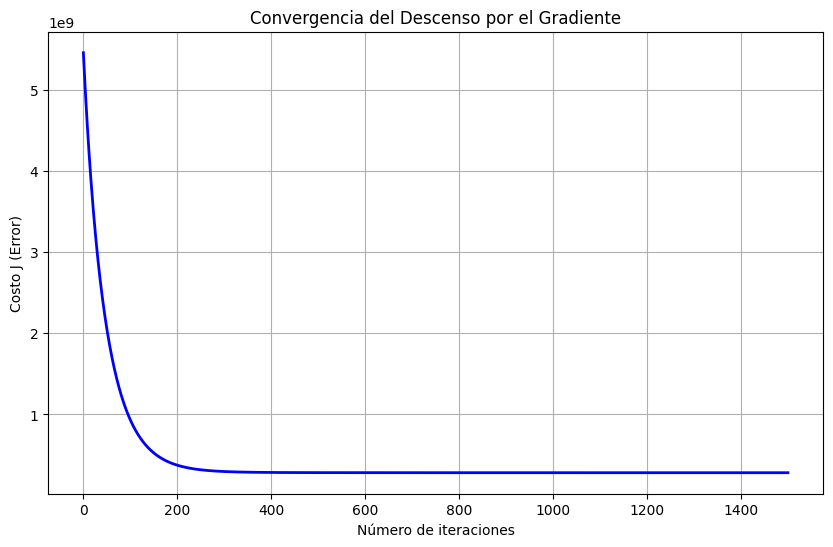

In [56]:
# Creamos la figura
pyplot.figure(figsize=(10, 6))

# Graficamos el historial de costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')

pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J (Error)')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.grid(True)

# Mostramos el gráfico del historial de costo
pyplot.show()

## Regresión Polinomica

## Usaremos los mismos 25000 datos para entrenar a este modelo
##

In [57]:
# Seleccionamos las 20 columnas originales de los 25000 datos
X_poly = df[columnas_20].head(25000).values
y = df['salary_usd'].head(25000).values

# Creamos la columna de experiencia al cuadrado
# Hacemos reshape para que sea una columna vertical
exp_sq = (X_poly[:, 0] ** 2).reshape(-1, 1)

# Unir la columna cuadrada a las 20 originales
# Ahora son 21 columnas
X_poly = np.hstack([X_poly, exp_sq])

# Normalizar necesario por el tamaño de los datos
mu = np.mean(X_poly, axis=0)
sigma = np.std(X_poly, axis=0)
X_poly_norm = (X_poly - mu) / sigma

# Añadimos la columna de unos
# Total 22 columnas
m = y.size
X_poly_ready = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

### Entrenamiento

## Cálculo de la Gradiente

In [58]:
def gradientDescentMulti(X, y, theta_poly, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta_poly = theta_poly.copy()

    J_history = []

    for i in range(num_iters):
        theta_poly = theta_poly - (alpha / m) * (np.dot(X, theta_poly) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta_poly))

    return theta_poly, J_history

## Cálculo del Costo

In [59]:
def computeCostMulti(X, y, theta_poly):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta_poly)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta_poly) - y))

    return J

In [60]:
# Inicializa para 22 parámetros
theta_poly = np.zeros(22)

# Configuraciones (puedes ajustar alpha y num_iters)
alpha = 0.01
num_iters = 5000

# Usas tus funciones tal cual las tienes
theta_poly, J_history = gradientDescentMulti(X_poly_ready, y, theta_poly, alpha, num_iters)

print(f"Costo final Polinómico: {J_history[-1]}")

Costo final Polinómico: 280211580.3810734


### Gráfico de Costo

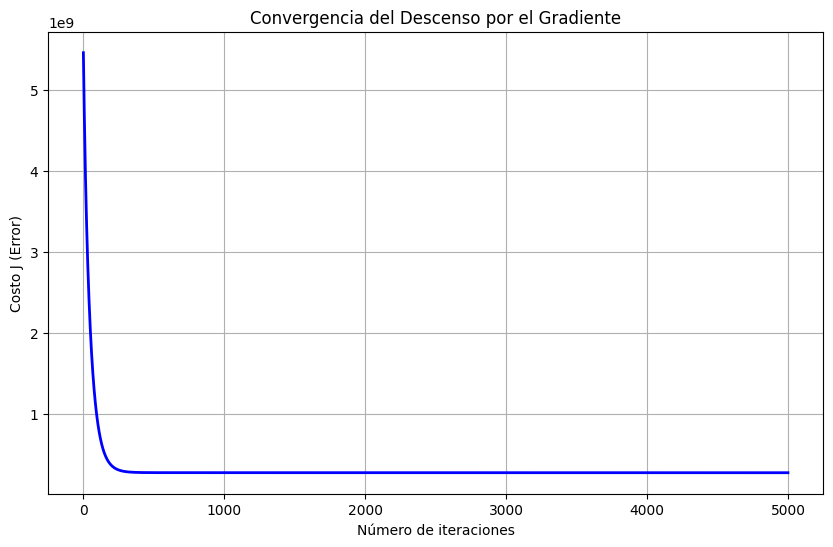

In [61]:
# Crear la figura
pyplot.figure(figsize=(10, 6))

# Graficar el historial de costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')

pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J (Error)')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.grid(True)

pyplot.show()

## Ecuación de la Normal

In [62]:
def ecuacionNormal(X, y):
    # Formula: theta = (X^T * X)^-1 * X^T * y
    # np.linalg.inv es para la matriz inversa
    theta = np.dot(np.linalg.inv(np.dot(X.T, X)), X.T)
    theta = np.dot(theta, y)
    return theta

In [63]:
# Preparamos los datos, no es necesario normalizar
X_norm_eq = df[columnas_20].head(25000).values
y_norm_eq = df['salary_usd'].head(25000).values
m_eq = y_norm_eq.size

# 2. Añadir columna de unos
X_norm_eq = np.concatenate([np.ones((m_eq, 1)), X_norm_eq], axis=1)

# 3. Calcular Theta directamente
theta_normal = ecuacionNormal(X_norm_eq, y_norm_eq)

print(f"Theta encontrado por Ecuación de la Normal (primeros 5 valores): {theta_normal[:5]}")

Theta encontrado por Ecuación de la Normal (primeros 5 valores): [ 3.33915793e+04  3.34612831e+03  2.83011007e+00 -1.44318073e+02
 -2.08014883e+01]


## Gráfico del Costo

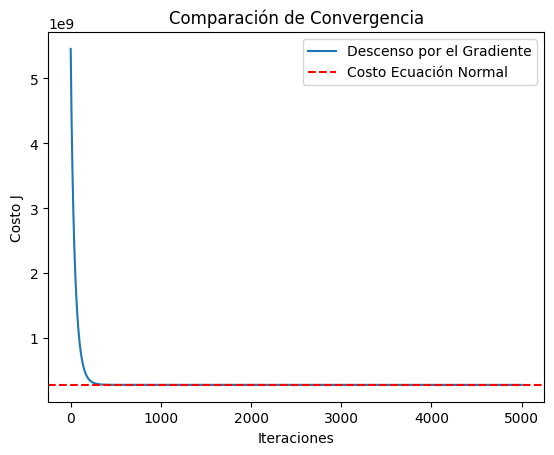

In [64]:
# Calculamos el costo único de la Normal
costo_normal = computeCostMulti(X_norm_eq, y_norm_eq, theta_normal)

# Graficamos el historial del gradiente y una línea para la normal
pyplot.plot(J_history, label='Descenso por el Gradiente')
pyplot.axhline(y=costo_normal, color='r', linestyle='--', label='Costo Ecuación Normal')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Comparación de Convergencia')
pyplot.legend()

### A diferencia del Descenso por el Gradiente, la Ecuación de la Normal encuentra los parámetros óptimos de forma analítica mediante la fórmula $\theta = (X^T X)^{-1} X^T y$. Al no ser un método iterativo, no existe un historial de costos ($J\_history$) para graficar, el modelo alcanza el mínimo global en un solo paso.

## 100 predicciones:
### Como el dataset tiene mas de 25000 datos ( que es la cantidad que usamos para entrenar ) podemos usar los datos desde 25001 para adelante para comprobar nuestros modelos

In [65]:
# Extraer 100 filas nuevas para prueba
X_test_raw = df[columnas_20].iloc[25000:25100].values
y_test_real = df[variable_objetivo].iloc[25000:25100].values

# Preparar los datos para cada modelo
# Para Multivariable y Polinómica requieren normalización
X_test_norm = (X_test_raw - X_mean) / X_std
X_test_mult = np.concatenate([np.ones((100, 1)), X_test_norm], axis=1)

X_test_poly_raw = np.hstack([X_test_raw, (X_test_raw[:, 0]**2).reshape(-1, 1)])
X_test_poly_norm = (X_test_poly_raw - mu) / sigma
X_test_poly = np.concatenate([np.ones((100, 1)), X_test_poly_norm], axis=1)

# Para Ecuación Normal sin normalizar
X_test_normal_eq = np.concatenate([np.ones((100, 1)), X_test_raw], axis=1)

# Realizar las predicciones
pred_mult = np.dot(X_test_mult, theta)
pred_poly = np.dot(X_test_poly, theta_poly)
pred_norm = np.dot(X_test_normal_eq, theta_normal)

# Tabla comparativa
comparativa = pd.DataFrame({
    'Salario Real': y_test_real,
    'Pred. Multivariable': pred_mult,
    'Pred. Polinómica': pred_poly,
    'Pred. Ec. Normal': pred_norm
})

print(comparativa)

    Salario Real  Pred. Multivariable  Pred. Polinómica  Pred. Ec. Normal
0         106313         98187.334009      99618.396410      97993.659231
1          76912         56396.118507      55539.202619      56772.113573
2         154387        142455.396929     142523.353669     142367.764607
3          65504         79377.091664      79209.396303      79453.842876
4          88742         68633.364430      68754.608684      68774.379998
..           ...                  ...               ...               ...
95        119923        126915.464194     126024.907670     126893.274549
96         95348         80681.463062      81682.896574      80548.873132
97         80490         90570.083425      91281.269633      90472.522150
98         52995         79861.552721      78930.016847      80273.798385
99        138701        107090.395852     105591.825419     107114.722677

[100 rows x 4 columns]


## Podemos ver como los 3 modelos funcionan como deberían, todos esos modelos muestran diferencias en como predicen un dato, y, mientras la predicción multivariable y la predicción de la ecuación de la normal son más cercanas a al dato real que la predicción polinómica, esta última no se queda atrás y tambien muestra un buen acercamiento al vdato rela.